# Modeling and Experimentation (With/Without ACLED)

From our EDA, we've made the following hypotheses/statements which we will test and verify:

- Baseline modeling will be done by first only predicting the average arrival for every month/year
- Linear regression can be used to supplement our baseline by giving us indications on which features to focus on
- Decision Tree based models using either Boosting or Random Forests will generate the most accurate results 

We decided not to use a neural network (RNN) due to the limited number of labels available. In fact, any deep-learning style approach will most likely result in overfitting on the training data due to the limited sample size of the I-94 arrival data.

The ACLED dataset is particularly interesting, mostly because the prior experiments we ran using ACLED resulted in the ACLED coefficient being much larger than any others. Because ACLED data is only from 2020 onwards, this made it difficult to account for it fairly for the entirety of the I-94 dataset. Therefore, here we run three different models:
- A full non-ACLED model (2010-2024), which accounts for ~57% of the I-94 dataset but does not include any ACLED incidents
- Two condensed models (2020 onward): one with ACLED and one without ACLED. We want to use these two models to isolate the effects of ACLED to determine how important the events in that dataset affected the I-94 arrival data.

***Note that dropping NaNs on our full feature set narrows us to 2010-2024. GDP coverage is the binding constraint here, not the I-94 data, which means our long-history model uses roughly 57% of the arrivals we have.***

## Import Libraries and Load Data

In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

The filepaths below use local filepaths: if running on a local machine be sure to change them as required

In [2]:
df_i94     = pd.read_csv("/Users/abbykreutz/github/MIDS207_FinalProject/Peter_EDA/label_arrivals_cleaned.csv")  # Label: total visitors
df_party   = pd.read_csv("/Users/abbykreutz/github/MIDS207_FinalProject/Peter_EDA/features_party_cleaned.csv")  # Feature: Political control
df_tourism = pd.read_csv("/Users/abbykreutz/github/MIDS207_FinalProject/Hope_EDA/features_inbound_cleaned.csv") # Feature: Inbound Tourism
df_gdp     = pd.read_csv("/Users/abbykreutz/github/MIDS207_FinalProject/Hope_EDA/features_gdp_cleaned.csv")     # Feature: Tourism % GDP
df_acled   = pd.read_csv("/Users/abbykreutz/github/MIDS207_FinalProject/Abby_EDA/features_acled_cleaned.csv")   # Feature: Armed conflict data
df_acledv2 = pd.read_csv("/Users/abbykreutz/github/MIDS207_FinalProject/Abby_EDA/features_acled_extended.csv")  # Additional ACLED Feature Set

## Feature Engineering, and Train/Test Split

### Feature Engineering (Political Party in Power, GDP/Tourism, and ACLED)

First we'll look at political features from the political party in control dataset. We want to include transitional features which gave more insight than simply which party was in power at a given time

In [3]:
# Map each year to the corresponding Congress using start_year
df_party["start_year"] = df_party["years"].str[:4].astype(int)
df_party["end_year"]   = df_party["years"].str[-4:].astype(int)

def get_congress_row(year, df_party):
    mask = (df_party["start_year"] <= year) & (df_party["end_year"] > year)
    return df_party[mask].iloc[0] if mask.any() else None

# Binary encode political features
df_party["is_rep_house"]    = df_party["house_majority"].eq("Republicans").astype(int)
df_party["is_rep_senate"]   = df_party["senate_majority"].str.startswith("Republicans").astype(int)
df_party["is_rep_president"]= df_party["presidency"].str.startswith("Republican").astype(int)
df_party["is_unified"]      = df_party["party_government"].eq("Unified").astype(int)

# Transition features (did control change vs previous Congress?)
df_party["house_changed"]   = (df_party["is_rep_house"] != df_party["is_rep_house"].shift()).astype(int)
df_party["senate_changed"]  = (df_party["is_rep_senate"] != df_party["is_rep_senate"].shift()).astype(int)
df_party["pres_changed"]    = (df_party["is_rep_president"] != df_party["is_rep_president"].shift()).astype(int)

political_features = [
    "is_rep_house", "is_rep_senate", "is_rep_president",
    "is_unified", "house_changed", "senate_changed",
    "pres_changed"
]

# Expand each two-year congressional period into one row per calendar year

party_yearly = (df_party[political_features     # Select all political_features.
    + ["start_year", "end_year"]].assign(       # Plus start_year and end_year columns,
        year=lambda x: x.apply(                 # and a new column, year, that we'll populate.
            lambda row: list(range(             # We create a list of years ranging from
                int(row["start_year"]),         # the start_year of the congressional period
                int(row["end_year"])            # through the end_year (exclusive, so as not to double count!)
                )
            ),
        axis=1                                  # lambda function is applied row-by-row across columns
        )
    )
    .explode("year")                            # transform list of years into dataframe with political feature flags
)

party_yearly["year"] = party_yearly["year"].astype(int)
party_yearly = party_yearly[political_features + ["year"]].set_index("year")

# Each calendar year should map to exactly one Congress
assert not party_yearly.index.duplicated().any()

Next we'll look at election years as another feature: 

In [4]:
# Presidential election years (every 4 years)
df_i94["is_election_year"] = df_i94["year"].isin(
    range(2000, 2027, 4)                                 
).astype(int)

Merge all features into one dataset and filter from 2000-2026 (to match the I-94 dataset).

One thing to be careful about here: tourism and GDP are **annual**, so merging them on `year` broadcasts
the full-year figure onto every month of that year. That means predicting January 2023 would hand the
model the 2023 annual tourism total, which includes February through December 2023 — months that haven't
happened yet from the model's point of view. This is target leakage, and it's worth taking seriously
because annual tourism correlates 0.69 with annual summed arrivals, so the feature is partly a compressed
copy of what we're trying to predict.

The fix is to shift both sources forward by one year. Each month then carries the last *completed* year's
figure, which is genuinely knowable at prediction time (in January 2023 we really do know 2022's numbers).

In [5]:
# Shifted tourism and GDP forward one year to avoid data/target leakage
df_tourism_lagged = df_tourism.assign(year=df_tourism["year"] + 1)
df_gdp_lagged     = df_gdp.assign(year=df_gdp["year"] + 1)

df = df_i94.merge(party_yearly, on="year", how="left", validate="many_to_one")
df = df.merge(df_tourism_lagged, on="year", how="left")
df = df.merge(df_gdp_lagged, on="year", how="left")
df = df.merge(df_acledv2, on="date", how="left")

df = df[(df["year"] >= 2000) & (df["year"] <= 2026)].sort_values("date").reset_index(drop=True)

print(f"Merged rows: {len(df)}  ({df['date'].min()} to {df['date'].max()})")
print(f"Rows with ACLED coverage: {df['acled_incidents'].notna().sum()}")

Merged rows: 315  (2000-01-01 to 2026-03-01)
Rows with ACLED coverage: 67


Historical context oftentimes matters so we'll include three lag features and one rolling average feature as well as seasonal encoding.
- Our lag features will include arrivals from one and two months prior (separate features), and from the same month in the previous year to account for seasonal patterns in international tourism
- Our rolling feature will account for three month average of past arrivals. This requires us to shift by 1 in order to address potential leakage.
- Sine/cosine transforms capture the cyclical nature of months (to prevent an artificial gap between December and January)
- The ACLED lag and rolling columns are already in `features_acled_extended.csv`, so here we only backfill the leading NaNs inside the ACLED window


In [6]:
df = df.sort_values("date").reset_index(drop=True)

# Arrival lag features
df["arrivals_lag_1"]  = df["total_arrivals"].shift(1)
df["arrivals_lag_2"]  = df["total_arrivals"].shift(2)
df["arrivals_lag_12"] = df["total_arrivals"].shift(12)
df["arrivals_roll_3"] = df["total_arrivals"].shift(1).rolling(window=3).mean()

# Seasonal encoding
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

# ACLED lag / rolling features
# Inside the ACLED window, the only NaNs are the first one and two months because
# there are no prior observations; we fill those with 0. Outside the window (pre-2020)
# the values stay NaN so the long-history model can still exclude them.
acled_lag_cols = [
    "acled_events_lag_1", "acled_events_lag_2", "acled_events_roll_3",
    "acled_fatal_events_lag_1", "acled_fatal_events_lag_2", "acled_fatalities_roll_3",
]
in_acled_window = df["acled_incidents"].notna()
for col in acled_lag_cols:
    df.loc[in_acled_window, col] = df.loc[in_acled_window, col].fillna(0)

# Short aliases used later in the notebook
df["acled_lag_1"]  = df["acled_events_lag_1"]
df["acled_lag_2"]  = df["acled_events_lag_2"]
df["acled_roll_3"] = df["acled_events_roll_3"]


Now we'll define our features and label constants:

In [7]:
LABEL = "total_arrivals"

FEATURES = [
    # Political
    "is_rep_house", "is_rep_senate", "is_rep_president",
    "is_unified", "house_changed", "senate_changed",
    "pres_changed", "is_election_year",
    # Tourism
    "tourism_value", "tourism_pct_change", "gdp_value", "gdp_pct_change",
    # Lag and rolling features
    "arrivals_lag_1", "arrivals_lag_2", "arrivals_lag_12", "arrivals_roll_3", "month_sin", "month_cos",
]

In [8]:
df_full = df.dropna(subset= FEATURES + [LABEL]).copy().reset_index(drop=True)

X = df_full[FEATURES]
y = df_full[LABEL]

And we'll do the same for ACLED:

In [9]:
# Core time-series signal, shared by every recent-period model
FEATURES_NO_ACLED = [
    "arrivals_lag_1",
    "arrivals_lag_12",
    "arrivals_roll_3",
    "month_sin",
    "month_cos",
]

# Every ACLED column available in the extended export
ACLED_FEATURE_SET = [
    "acled_incidents",
    "acled_fatal_events",
    "acled_total_fatalities",
    "acled_any_event",
    "acled_any_fatal_event",
    "acled_high_activity_flag",
    "acled_events_lag_1",
    "acled_fatal_events_lag_1",
    "acled_events_lag_2",
    "acled_fatal_events_lag_2",
    "acled_events_roll_3",
    "acled_fatalities_roll_3",
    "acled_states",
    "acled_event_types",
]

# Full feature set, used as the starting point, then narrowed down
FEATURES_WITH_ACLED = FEATURES_NO_ACLED + ACLED_FEATURE_SET

print(f"No-ACLED features   : {len(FEATURES_NO_ACLED)}")
print(f"With-ACLED features : {len(FEATURES_WITH_ACLED)}")


No-ACLED features   : 5
With-ACLED features : 19


### Train/Test Split and Feature Scaling 

Because we are using chronological data, we will NOT be using random splitting for our data. Instead, we need to delineate a cutoff between the two datasets. In this case, we will use Jan 2022. 

In [10]:
split_date = "2022-01-01"

# Build mask from df_full
train_mask_full = df_full["date"] < split_date

X_train, X_test = X[train_mask_full], X[~train_mask_full]
y_train, y_test = y[train_mask_full], y[~train_mask_full]

print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")
print(
    f"Training period: {df_full.loc[train_mask_full, 'date'].min()} "
    f"to {df_full.loc[train_mask_full, 'date'].max()}"
)

Train size: 144 | Test size: 36
Training period: 2010-01-01 to 2021-12-01


In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  
X_test_scaled  = scaler.transform(X_test)

We also create a copy of the data to use for an ACLED model that only accounts for data beginning January 2020.

In [12]:
df_acled_model = (
    df[df["date"] >= "2020-01-01"]
    .dropna(subset=FEATURES_WITH_ACLED + [LABEL])
    .copy()
    .reset_index(drop=True)
)

acled_split_date = "2023-01-01"
acled_mask = df_acled_model["date"] < acled_split_date

X_train_acled    = df_acled_model.loc[acled_mask,  FEATURES_WITH_ACLED]
X_test_acled     = df_acled_model.loc[~acled_mask, FEATURES_WITH_ACLED]
y_train_acled    = df_acled_model.loc[acled_mask,  LABEL]
y_test_acled     = df_acled_model.loc[~acled_mask, LABEL]

X_train_no_acled = df_acled_model.loc[acled_mask,  FEATURES_NO_ACLED]
X_test_no_acled  = df_acled_model.loc[~acled_mask, FEATURES_NO_ACLED]
y_train_no_acled    = df_acled_model.loc[acled_mask,  LABEL]
y_test_no_acled     = df_acled_model.loc[~acled_mask, LABEL]

print(f"ACLED train size: {len(X_train_acled)} | Test size: {len(X_test_acled)}")
print(
    f"Training period: {df_acled_model.loc[acled_mask, 'date'].min()} "
    f"to {df_acled_model.loc[acled_mask, 'date'].max()}"
)

ACLED train size: 36 | Test size: 31
Training period: 2020-01-01 to 2022-12-01


In [13]:
acled_scaler = StandardScaler()
no_acled_scaler = StandardScaler()

X_train_acled_scaled = acled_scaler.fit_transform(X_train_acled)  
X_test_acled_scaled  = acled_scaler.transform(X_test_acled)

X_train_no_acled_scaled = no_acled_scaler.fit_transform(X_train_no_acled) 
X_test_no_acled_scaled  = no_acled_scaler.transform(X_test_no_acled)

## Non-ACLED Model Baseline/Experimentation

### Baseline 1: Predict the number of visitors using the average

This first baseline is very simple: calculate and predict the mean number of visitors from y_train every time.

In [14]:
avg_baseline = y_train.mean()
avg_baseline_pred = np.full(len(y_test), avg_baseline)

In [15]:
# Evaluate against actual test-period arrivals
rmse = np.sqrt(mean_squared_error(y_test, avg_baseline_pred))
mae = mean_absolute_error(y_test, avg_baseline_pred)
r2 = r2_score(y_test, avg_baseline_pred)

print(f"Mean Baseline — predicting {avg_baseline:,.0f} arrivals every month\n")
print(f"RMSE : {rmse:>12,.0f}")
print(f"MAE  : {mae:>12,.0f}")
print(f"R²   : {r2:>12.4f}")

Mean Baseline — predicting 5,343,919 arrivals every month

RMSE :    1,125,259
MAE  :      841,561
R²   :      -0.0054


### Baseline 2: Use Linear Regression to predict number of visitors

Our second baseline will use LR to generate predictions with our features. Because we don't anticipate a linear relationship between our features and label, we don't expect high performance. However for the sake of a baseline model, this will more than suffice.

In [16]:
# Baseline no. 2: predict number of visitors using LR 
lr_baseline = LinearRegression()
lr_baseline.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [17]:
# Evaluate against actual test-period arrivals
lr_baseline_pred = lr_baseline.predict(X_test_scaled)

rmse = np.sqrt(mean_squared_error(y_test, lr_baseline_pred))
mae  = mean_absolute_error(y_test, lr_baseline_pred)
r2   = r2_score(y_test, lr_baseline_pred)

print(f"RMSE : {rmse:,.0f}")
print(f"MAE  : {mae:,.0f}")
print(f"R²   : {r2:.4f}")

RMSE : 60,160,974
MAE  : 50,218,580
R²   : -2872.7939


In [18]:
# Display coefficients for each feature to determine significance
coef_df = pd.DataFrame({
    "feature"    : FEATURES,
    "coefficient": lr_baseline.coef_
}).sort_values("coefficient", ascending=False)

print(coef_df.to_string(index=False))

           feature   coefficient
  is_rep_president  1.980488e+07
tourism_pct_change  1.730870e+07
    senate_changed  1.660667e+07
         gdp_value  1.126844e+07
   arrivals_roll_3  1.281066e+06
    arrivals_lag_1  5.703657e+05
   arrivals_lag_12  5.066092e+05
  is_election_year  7.908270e+04
         month_sin -2.434822e+04
         month_cos -2.066427e+05
        is_unified -5.271037e+05
      pres_changed -5.271037e+05
    arrivals_lag_2 -7.011047e+05
     house_changed -1.062852e+06
      is_rep_house -1.778013e+06
    gdp_pct_change -3.891667e+06
     tourism_value -1.547394e+07
     is_rep_senate -1.829621e+07


Our coefficients are indicating the model his having a difficult time determining what features are most significant. This is seen with how many repeat coefficients there are across feature. We did not anticipate any of these relationships to be linear, therefore further experimentation will be used to determine what models will be best suited for this data and problem set.

### Experimentation (RF and XGBoost)

In this section we will test two models and compare them to baseline: the first will be a Random Forest and the second will be a gradient booster with XGBoost. We will be using the unscaled version of our features for these two models since they are decision trees.

In [19]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    mae = mean_absolute_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)

    print(f"{name}")
    print(f"RMSE : {rmse:,.0f}")
    print(f"MAE  : {mae:,.0f}")
    print(f"R²   : {r2:.4f}")
    print()

    return {
        "model": name,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "predictions": predictions
    }

results = []

# Random forest does not require feature scaling.
rf_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=3,
    min_samples_leaf=2,
    max_features=0.8,
    random_state=42,
    n_jobs=-1
)

results.append(
    evaluate_model(
        "Random Forest",
        rf_model,
        X_train,
        y_train,
        X_test,
        y_test
    )
)

# XGBoost also does not require feature scaling.
xgb_model = XGBRegressor(
    n_estimators=250,
    max_depth=2,
    learning_rate=0.03,
    min_child_weight=2,
    subsample=0.8,
    colsample_bytree=0.9,
    reg_lambda=5,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=1
)

results.append(
    evaluate_model(
        "XGBoost",
        xgb_model,
        X_train,
        y_train,
        X_test,
        y_test
    )
)

results_df = pd.DataFrame(results).drop(columns=["predictions"])
results_df.sort_values("RMSE")

Random Forest
RMSE : 594,103
MAE  : 460,445
R²   : 0.7197

XGBoost
RMSE : 557,709
MAE  : 460,561
R²   : 0.7530



,model,RMSE,MAE,R2
1,XGBoost,557708.925277,460561.298611,0.753032
0,Random Forest,594103.052768,460444.603509,0.719748


### Tuning and Optimization

Now that we've run both Random Forst and XGBoost, our goal will be to determine how best to optimize our models for performance. 

In [20]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

def tune_random_forest(X_train, y_train, n_iter=20):
    """
    Tune Random Forest using chronological validation folds.
    Does not use the held-out test set.
    """
    tscv = TimeSeriesSplit(n_splits=3)

    rf = RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    )

    rf_param_grid = {
        "n_estimators": [100, 200, 300, 500, 750],
        "max_depth": [2, 3, 4, 5, 6, None],
        "min_samples_split": [2, 3, 4, 5, 6, 8],
        "min_samples_leaf": [1, 2, 3, 4, 5],
        "max_features": [0.5, 0.7, 0.8, 1.0],
        "bootstrap": [True, False]
    }

    rf_search = RandomizedSearchCV(
        estimator=rf,
        param_distributions=rf_param_grid,
        n_iter=n_iter,
        scoring="neg_root_mean_squared_error",
        cv=tscv,
        random_state=42,
        n_jobs=-1,
        verbose=1,
        refit=True
    )

    rf_search.fit(X_train, y_train)

    print("Best Random Forest validation RMSE:")
    print(f"{-rf_search.best_score_:,.0f}")
    print("\nBest Random Forest parameters:")
    print(rf_search.best_params_)

    return rf_search

In [21]:
def tune_xgboost(X_train, y_train, n_iter=25):
    """
    Tune XGBoost using chronological validation folds.
    Does not use the held-out test set.
    """
    tscv = TimeSeriesSplit(n_splits=3)

    xgb = XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        n_jobs=1
    )

    xgb_param_grid = {
        "n_estimators": [100, 150, 200, 250, 300, 400, 500],
        "max_depth": [1, 2, 3, 4, 5],
        "learning_rate": [0.01, 0.02, 0.03, 0.05, 0.08, 0.1],
        "min_child_weight": [1, 2, 3, 4, 5],
        "subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
        "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
        "reg_alpha": [0, 0.01, 0.1, 0.5, 1.0],
        "reg_lambda": [1, 3, 5, 10, 20]
    }

    xgb_search = RandomizedSearchCV(
        estimator=xgb,
        param_distributions=xgb_param_grid,
        n_iter=n_iter,
        scoring="neg_root_mean_squared_error",
        cv=tscv,
        random_state=42,
        n_jobs=-1,
        verbose=1,
        refit=True
    )

    xgb_search.fit(X_train, y_train)

    print("Best XGBoost validation RMSE:")
    print(f"{-xgb_search.best_score_:,.0f}")
    print("\nBest XGBoost parameters:")
    print(xgb_search.best_params_)

    return xgb_search

In [22]:
# =============================================================================
# 1. LONG-HISTORY MODEL: 2000+ data, no ACLED features
# =============================================================================

print("=" * 70)
print("TUNING LONG-HISTORY RANDOM FOREST")
print("=" * 70)

rf_long_search = tune_random_forest(X_train, y_train, n_iter=20)

print("\n" + "=" * 70)
print("TUNING LONG-HISTORY XGBOOST")
print("=" * 70)

xgb_long_search = tune_xgboost(X_train, y_train, n_iter=25)

TUNING LONG-HISTORY RANDOM FOREST
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Random Forest validation RMSE:
1,415,106

Best Random Forest parameters:
{'n_estimators': 200, 'min_samples_split': 6, 'min_samples_leaf': 3, 'max_features': 0.7, 'max_depth': 6, 'bootstrap': False}

TUNING LONG-HISTORY XGBOOST
Fitting 3 folds for each of 25 candidates, totalling 75 fits
Best XGBoost validation RMSE:
1,383,602

Best XGBoost parameters:
{'subsample': 1.0, 'reg_lambda': 1, 'reg_alpha': 0, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 4, 'learning_rate': 0.03, 'colsample_bytree': 0.8}


In [23]:
def evaluate_tuned_model(name, search, X_test, y_test):
    model = search.best_estimator_
    predictions = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    mae = mean_absolute_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)

    print(f"\n{name}")
    print(f"RMSE : {rmse:,.0f}")
    print(f"MAE  : {mae:,.0f}")
    print(f"R²   : {r2:.4f}")

    return {
        "model": name,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "best_params": search.best_params_
    }

In [24]:
tuned_results = []

# Long-history models
tuned_results.append(
    evaluate_tuned_model(
        "Tuned RF — Long History",
        rf_long_search,
        X_test,
        y_test
    )
)

tuned_results.append(
    evaluate_tuned_model(
        "Tuned XGB — Long History",
        xgb_long_search,
        X_test,
        y_test
    )
)


Tuned RF — Long History
RMSE : 780,255
MAE  : 670,333
R²   : 0.5166

Tuned XGB — Long History
RMSE : 581,359
MAE  : 499,689
R²   : 0.7316


## ACLED Modeling/Experimentation

What if we now include the ACLED data? Of note, because ACLED only goes from 2020-2026 we will only consider data in that range but keep the rest of the features to be similar

In [25]:
# ── Mean Baseline ──────────────────────────────────────────────────────────────

avg_baseline_acled    = y_train_acled.mean()
avg_baseline_no_acled = y_train_no_acled.mean()

avg_pred_acled    = np.full(len(y_test_acled),    avg_baseline_acled)
avg_pred_no_acled = np.full(len(y_test_no_acled), avg_baseline_no_acled)

for label, y_test_exp, preds in [
    ("Mean Baseline (No ACLED)", y_test_no_acled, avg_pred_no_acled),
    ("Mean Baseline (With ACLED)", y_test_acled,  avg_pred_acled),
]:
    rmse = np.sqrt(mean_squared_error(y_test_exp, preds))
    mae  = mean_absolute_error(y_test_exp, preds)
    r2   = r2_score(y_test_exp, preds)
    print(f"{label} — predicting {preds[0]:,.0f} arrivals every month")
    print(f"  RMSE : {rmse:>12,.0f}")
    print(f"  MAE  : {mae:>12,.0f}")
    print(f"  R²   : {r2:>12.4f}\n")

Mean Baseline (No ACLED) — predicting 2,562,856 arrivals every month
  RMSE :    3,238,637
  MAE  :    3,161,565
  R²   :     -20.2633

Mean Baseline (With ACLED) — predicting 2,562,856 arrivals every month
  RMSE :    3,238,637
  MAE  :    3,161,565
  R²   :     -20.2633



In [26]:
# ── Linear Regression Baseline ────────────────────────────────────────────────

acled_scaler    = StandardScaler()
no_acled_scaler = StandardScaler()

X_train_acled_scaled    = acled_scaler.fit_transform(X_train_acled)
X_test_acled_scaled     = acled_scaler.transform(X_test_acled)

X_train_no_acled_scaled = no_acled_scaler.fit_transform(X_train_no_acled)
X_test_no_acled_scaled  = no_acled_scaler.transform(X_test_no_acled)

for label, X_tr, X_te, y_tr, y_te, feats in [
    ("LR Baseline (No ACLED)",   X_train_no_acled_scaled, X_test_no_acled_scaled,
     y_train_no_acled, y_test_no_acled, FEATURES_NO_ACLED),
    ("LR Baseline (With ACLED)", X_train_acled_scaled,    X_test_acled_scaled,
     y_train_acled,    y_test_acled,    FEATURES_WITH_ACLED),
]:
    lr = LinearRegression().fit(X_tr, y_tr)
    preds = lr.predict(X_te)

    rmse = np.sqrt(mean_squared_error(y_te, preds))
    mae  = mean_absolute_error(y_te, preds)
    r2   = r2_score(y_te, preds)

    print(f"{label}")
    print(f"  RMSE : {rmse:>12,.0f}")
    print(f"  MAE  : {mae:>12,.0f}")
    print(f"  R²   : {r2:>12.4f}")

    coef_df = pd.DataFrame({"feature": feats, "coefficient": lr.coef_})
    coef_df = coef_df.reindex(coef_df["coefficient"].abs().sort_values(ascending=False).index)
    print(coef_df.to_string(index=False))
    print()

LR Baseline (No ACLED)
  RMSE :    1,175,435
  MAE  :      952,330
  R²   :      -1.8009
        feature   coefficient
 arrivals_lag_1  1.853233e+06
arrivals_roll_3 -3.485718e+05
arrivals_lag_12 -3.046568e+05
      month_sin -1.366529e+05
      month_cos  5.776666e+03

LR Baseline (With ACLED)
  RMSE :    1,400,947
  MAE  :    1,156,372
  R²   :      -2.9788
                 feature   coefficient
          arrivals_lag_1  2.313767e+06
         arrivals_roll_3 -5.806156e+05
         arrivals_lag_12 -4.951064e+05
            acled_states  3.596172e+05
      acled_fatal_events -3.219520e+05
               month_cos  2.953389e+05
     acled_events_roll_3 -2.479359e+05
         acled_incidents  2.432695e+05
acled_fatal_events_lag_2  2.010527e+05
acled_high_activity_flag  1.811984e+05
      acled_events_lag_1  1.050964e+05
   acled_any_fatal_event -8.809647e+04
 acled_fatalities_roll_3  8.059533e+04
  acled_total_fatalities  4.892897e+04
       acled_event_types  4.537128e+04
               

In [27]:
# ── Random Forest & XGBoost ───────────────────────────────────────────────────

acled_results = []

rf_params = dict(
    n_estimators=500, max_depth=3, min_samples_leaf=2,
    max_features=0.8, random_state=42, n_jobs=-1
)
xgb_params = dict(
    n_estimators=250, max_depth=2, learning_rate=0.03,
    min_child_weight=2, subsample=0.8, colsample_bytree=0.9,
    reg_lambda=5, objective="reg:squarederror", random_state=42, n_jobs=1
)

experiments = [
    ("RF  (No ACLED)",   RandomForestRegressor(**rf_params),  X_train_no_acled, y_train_no_acled, X_test_no_acled, y_test_no_acled),
    ("RF  (With ACLED)", RandomForestRegressor(**rf_params),  X_train_acled,    y_train_acled,    X_test_acled,    y_test_acled),
    ("XGB (No ACLED)",   XGBRegressor(**xgb_params),          X_train_no_acled, y_train_no_acled, X_test_no_acled, y_test_no_acled),
    ("XGB (With ACLED)", XGBRegressor(**xgb_params),          X_train_acled,    y_train_acled,    X_test_acled,    y_test_acled),
]

for name, model, X_tr, y_tr, X_te, y_te in experiments:
    acled_results.append(evaluate_model(name, model, X_tr, y_tr, X_te, y_te))

acled_results_df = pd.DataFrame(acled_results).drop(columns=["predictions"])
print("\nACLED Experiment Summary:")
print(acled_results_df.sort_values("RMSE").to_string(index=False))

RF  (No ACLED)
RMSE : 1,153,603
MAE  : 967,100
R²   : -1.6979

RF  (With ACLED)
RMSE : 1,149,186
MAE  : 970,446
R²   : -1.6772

XGB (No ACLED)
RMSE : 1,215,875
MAE  : 896,250
R²   : -1.9970

XGB (With ACLED)
RMSE : 1,217,218
MAE  : 926,079
R²   : -2.0036


ACLED Experiment Summary:
           model         RMSE           MAE        R2
RF  (With ACLED) 1.149186e+06 970445.795029 -1.677232
  RF  (No ACLED) 1.153603e+06 967100.014428 -1.697856
  XGB (No ACLED) 1.215875e+06 896249.991935 -1.996976
XGB (With ACLED) 1.217218e+06 926079.411290 -2.003603


### ACLED Feature Selection

The expanded ACLED export gives us 14 candidate features. Including our 5 core time-series features,
we are currently using 19 predictors total against 36 rows of data. Once the number of features approaches the
number of rows, ordinary least squares can overfit the training set instead of learning pattern or trends.

So before we tune anything, we need to prune. We rank the ACLED features three different ways —
each of them computed on the **training split only** — and then keep the features that all three agree on:

1. **Incremental cross-validation gain.** Add one ACLED feature at a time and measure how much the `TimeSeriesSplit` RMSE improves.
2. **Lasso.** L1 shrinks uninformative coefficients to exactly zero, which will tell us
   which features survive regularisation and are important predictors.
3. **Random Forest permutation importance.** A non-linear, model-based check that does not
   assume the relationship is linear.


In [28]:
from sklearn.linear_model import LassoCV, RidgeCV
from sklearn.pipeline import make_pipeline
from sklearn.inspection import permutation_importance
from sklearn.model_selection import cross_val_score

# Frame restricted to the ACLED window, with every candidate column present
df_sel = (
    df[df["date"] >= "2020-01-01"]
    .dropna(subset=FEATURES_NO_ACLED + ACLED_FEATURE_SET + [LABEL])
    .reset_index(drop=True)
)

sel_mask  = df_sel["date"] < acled_split_date
sel_train = df_sel[sel_mask]
sel_test  = df_sel[~sel_mask]

print(f"Selection frame : {len(df_sel)} rows ({df_sel['date'].min()} to {df_sel['date'].max()})")
print(f"Train           : {len(sel_train)} rows | Test: {len(sel_test)} rows")
print(f"Candidate ACLED features: {len(ACLED_FEATURE_SET)}")
print(f"Total features if we keep them all: {len(FEATURES_WITH_ACLED)}"
      f"  ->  {len(FEATURES_WITH_ACLED) / len(sel_train):.2f} features per training row")


Selection frame : 67 rows (2020-01-01 to 2025-07-01)
Train           : 36 rows | Test: 31 rows
Candidate ACLED features: 14
Total features if we keep them all: 19  ->  0.53 features per training row


A feature with no variance doesn't carry signal, and two features that have a strong linear relationship (collinearity) are redundant.

In [29]:
# ── Zero-variance check ───────────────────────────────────────────────────────
variance_check = sel_train[ACLED_FEATURE_SET ].std()
degenerate = variance_check[variance_check == 0].index.tolist()

print("Zero-variance ACLED features (dropped):")
print(f"  {degenerate}\n")

ACLED_USABLE = [c for c in ACLED_FEATURE_SET  if c not in degenerate]

# Near-constant features are almost as useless
near_const = [
    c for c in ACLED_USABLE
    if sel_train[c].nunique() <= 2 and sel_train[c].value_counts(normalize=True).max() > 0.90
]
print("Near-constant ACLED features (dropped):")
print(f"  {near_const}\n")

# ── Collinearity check ────────────────────────────────────────────────────────
corr = sel_train[ACLED_USABLE].corr().abs()
print("Highly collinear ACLED pairs (|r| > 0.85):")
for i, a in enumerate(ACLED_USABLE):
    for b in ACLED_USABLE[i + 1:]:
        if corr.loc[a, b] > 0.85:
            print(f"  {a:28s} ~ {b:28s} r = {corr.loc[a, b]:.3f}")


Zero-variance ACLED features (dropped):
  ['acled_any_event']

Near-constant ACLED features (dropped):
  ['acled_any_fatal_event']

Highly collinear ACLED pairs (|r| > 0.85):
  acled_incidents              ~ acled_states                 r = 0.912
  acled_events_lag_2           ~ acled_events_roll_3          r = 0.916


`acled_any_event` is constant — every month in the ACLED window had at least one politically violent event, so the flag is always 1 and contributes nothing. The same goes for `acled_any_fatal_event`. This goes to show that "more features" and "more information" are not the same thing, or always a good thing.

Now the three rankings.

In [30]:
tscv_sel = TimeSeriesSplit(n_splits=4)

def cv_rmse(cols):
    """Cross-validated RMSE on the training split only, using ridge to stay stable
    when the feature count is high relative to the row count."""
    model = make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-3, 4, 30)))
    scores = cross_val_score(
        model,
        sel_train[cols].values,
        sel_train[LABEL].values,
        cv=tscv_sel,
        scoring="neg_root_mean_squared_error",
    )
    return -scores.mean()

# ── 1. Incremental CV gain over the core set ──────────────────────────────────
core_cv = cv_rmse(FEATURES_NO_ACLED)
incremental = pd.Series(
    {c: core_cv - cv_rmse(FEATURES_NO_ACLED + [c]) for c in ACLED_USABLE}
)

# ── 2. Lasso ──────────────────────────────────────────────────────────────────
sel_scaler = StandardScaler().fit(sel_train[FEATURES_NO_ACLED + ACLED_USABLE])
X_sel = sel_scaler.transform(sel_train[FEATURES_NO_ACLED + ACLED_USABLE])

lasso = LassoCV(cv=tscv_sel, max_iter=200_000, random_state=42).fit(X_sel, sel_train[LABEL])
lasso_imp = pd.Series(
    np.abs(lasso.coef_), index=FEATURES_NO_ACLED + ACLED_USABLE
).loc[ACLED_USABLE]

# ── 3. Random Forest permutation importance ───────────────────────────────────
rf_sel = RandomForestRegressor(
    n_estimators=300, max_depth=3, min_samples_leaf=2,
    max_features=0.8, random_state=42, n_jobs=-1,
).fit(sel_train[FEATURES_NO_ACLED + ACLED_USABLE], sel_train[LABEL])

perm = permutation_importance(
    rf_sel,
    sel_train[FEATURES_NO_ACLED + ACLED_USABLE],
    sel_train[LABEL],
    n_repeats=15,
    random_state=42,
    scoring="neg_root_mean_squared_error",
)
perm_imp = pd.Series(
    perm.importances_mean, index=FEATURES_NO_ACLED + ACLED_USABLE
).loc[ACLED_USABLE]

# ── Consensus ─────────────────────────────────────────────────────────────────
ranking = pd.DataFrame({
    "incr_cv_gain":   incremental,
    "lasso_abs_coef": lasso_imp,
    "rf_perm_imp":    perm_imp,
})
ranking["mean_rank"] = ranking.rank(ascending=False).mean(axis=1)
ranking = ranking.sort_values("mean_rank")

print(f"W/out ACLEd features CV RMSE: {core_cv:,.0f}   (Lasso alpha = {lasso.alpha_:,.0f})\n")
print(ranking.round(1).to_string())


W/out ACLEd features CV RMSE: 1,602,225   (Lasso alpha = 394,644)

                          incr_cv_gain  lasso_abs_coef  rf_perm_imp  mean_rank
acled_incidents               168556.1             0.0      17681.5        4.0
acled_events_roll_3           132929.8             0.0      14132.1        4.7
acled_events_lag_1            224095.2             0.0       6396.0        5.7
acled_events_lag_2             64738.6             0.0      12808.0        5.7
acled_states                  676105.1             0.0       6063.3        5.7
acled_fatal_events           -121672.1             0.0      28384.6        6.3
acled_fatal_events_lag_1       49930.8             0.0       9097.1        6.3
acled_total_fatalities        128201.1             0.0       4216.5        7.3
acled_fatal_events_lag_2       24558.8             0.0       6459.3        7.3
acled_event_types            -290755.8             0.0       6474.1        8.3
acled_fatalities_roll_3      -102319.0             0.0       204

Two things stand out.

L1 regularization drives **every** ACLED coefficient to zero. Under L1 regularisation with
chronological cross-validation, not one ACLED variable earns its place once the arrival
lags and seasonal terms are already in the model. This is the clearest piece of
evidence that the extended feature set was being overfit, not learned.

The other two rankings still produce an ordering, and they broadly agree: the raw
event-count family (`acled_incidents`, `acled_events_roll_3`, `acled_events_lag_1`,
`acled_states`) sits at the top, while the severity and flag features
(`acled_high_activity_flag`, `acled_event_types`, `acled_any_fatal_event`,
`acled_total_fatalities`) sit at the bottom and in several cases make cross-validated RMSE
*worse*.

A greedy forward search confirms where the gains stop.

In [31]:
# ── Greedy forward feature selection on the training split ────────────────────────────
selected, current = [], core_cv
history = [("(core only)", core_cv, np.nan)]

while True:
    candidates = {
        c: cv_rmse(FEATURES_NO_ACLED + selected + [c])
        for c in ACLED_USABLE if c not in selected
    }
    if not candidates:
        break
    best = min(candidates, key=candidates.get)
    # Require a non-trivial improvement so we do not chase noise
    if candidates[best] >= current * 0.995:
        break
    history.append((best, candidates[best], current - candidates[best]))
    selected.append(best)
    current = candidates[best]

print(f"{'step':<6}{'feature added':<30}{'CV RMSE':>14}{'improvement':>14}")
for i, (feat, rmse, gain) in enumerate(history):
    gain_str = f"{gain:>14,.0f}" if not np.isnan(gain) else f"{'':>14}"
    print(f"{i:<6}{feat:<30}{rmse:>14,.0f}{gain_str}")

print(f"\nGreedy selection stopped at {len(selected)} ACLED feature(s): {selected}")


step  feature added                        CV RMSE   improvement
0     (core only)                        1,602,225              
1     acled_states                         926,119       676,105
2     acled_events_roll_3                  891,912        34,207

Greedy selection stopped at 2 ACLED feature(s): ['acled_states', 'acled_events_roll_3']


### Comparing the pruned feature set against the full feature set

Our forward feature selection rankings are computed on the training split, so we still need an honest
out-of-sample check. A single train/test split on 67 months is fragile: one unusual quarter (i.e., the
pandemic) can flip the verdict. Instead of trusting one split, we'll run a **walk-forward validation**.
We expand the training window month by month, predict the next six months, slide forward, and repeat.
This gives us nine consecutive test blocks instead of one, which means our comparison doesn't hinge on
where we happen to split the data.

We compare four things: the core feature set with no ACLED at all, the core set plus the top-3
consensus ACLED features, the core set plus all 13 usable ACLED features, and a seasonal
naive benchmark that simply predicts last year's same month.

### Choosing the final feature set

The greedy search and the consensus ranking disagree slightly, and the reason is
collinearity: `acled_states` and `acled_incidents` correlate at r = 0.91, so whichever one
enters the model first absorbs most of the shared signal and makes the other look redundant.

Instead we apply an explicit, reproducible rule and let the code derive the final list:

1. Walk the consensus ranking from best to worst.
2. Skip anything whose incremental CV RMSE gain is negative (if adding a
   feature makes cross-validation error worse, it does not belong in the model).
3. Skip anything correlated above |r| = 0.85 with a feature already selected.
4. Stop at three features, which keeps us near a 4:1 row-to-feature ratio on the 36-month
   training window.


In [32]:
# ── Derive the pruned ACLED set from the ranking, with explicit rules ─────────
MAX_ACLED_FEATURES = 3
COLLINEARITY_LIMIT = 0.85

ACLED_SELECTED = []
rejected = []

for feat in ranking.index:
    if len(ACLED_SELECTED) >= MAX_ACLED_FEATURES:
        break
    if ranking.loc[feat, "incr_cv_gain"] <= 0:
        rejected.append((feat, "negative incremental CV gain"))
        continue
    clash = [s for s in ACLED_SELECTED if corr.loc[feat, s] > COLLINEARITY_LIMIT]
    if clash:
        rejected.append((feat, f"collinear with {clash[0]} (r = {corr.loc[feat, clash[0]]:.2f})"))
        continue
    ACLED_SELECTED.append(feat)

print("Selected ACLED features:")
for f in ACLED_SELECTED:
    print(f"  KEEP    {f:28s} incr CV gain = {ranking.loc[f, 'incr_cv_gain']:>12,.0f}")
print("\nRejected along the way:")
for f, why in rejected:
    print(f"  DROP    {f:28s} {why}")

FEATURE_SETS = {
    "Core only (no ACLED)":  FEATURES_NO_ACLED,
    "Core + top-3 ACLED":    FEATURES_NO_ACLED + ACLED_SELECTED,
    "Core + all 13 ACLED":   FEATURES_NO_ACLED + ACLED_USABLE,
}

BACKTEST_MODELS = {
    "Ridge": lambda: make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-3, 4, 30))),
    "RF":    lambda: RandomForestRegressor(
        n_estimators=500, max_depth=3, min_samples_leaf=2,
        max_features=0.8, random_state=42, n_jobs=-1),
}

MIN_TRAIN, HORIZON, STEP = 36, 6, 3
origins = range(MIN_TRAIN, len(df_sel) - HORIZON + 1, STEP)

backtest = []
for origin in origins:
    bt_train = df_sel.iloc[:origin]
    bt_test  = df_sel.iloc[origin:origin + HORIZON]
    fold = str(bt_test["date"].iloc[0])[:7]

    backtest.append({
        "fold": fold, "feature_set": "Seasonal naive", "model": "-",
        "RMSE": np.sqrt(mean_squared_error(bt_test[LABEL], bt_test["arrivals_lag_12"])),
    })

    for set_name, cols in FEATURE_SETS.items():
        for model_name, make_model in BACKTEST_MODELS.items():
            model = make_model().fit(bt_train[cols], bt_train[LABEL])
            preds = model.predict(bt_test[cols])
            backtest.append({
                "fold": fold, "feature_set": set_name, "model": model_name,
                "RMSE": np.sqrt(mean_squared_error(bt_test[LABEL], preds)),
            })

backtest_df = pd.DataFrame(backtest)

print(f"\n{len(list(origins))}-folds cross-validation (per-fold RMSE,, in millions):")
print()
print(
    (backtest_df.pivot_table(index=["feature_set", "model"], columns="fold", values="RMSE") / 1e6)
    .round(2).to_string()
)

backtest_summary = (
    backtest_df.groupby(["feature_set", "model"])["RMSE"]
    .agg(["mean", "median", "std"])
    .sort_values("mean")
)
print("\nSummary:")
print(backtest_summary.round(0).to_string())


Selected ACLED features:
  KEEP    acled_incidents              incr CV gain =      168,556
  KEEP    acled_events_roll_3          incr CV gain =      132,930
  KEEP    acled_events_lag_1           incr CV gain =      224,095

Rejected along the way:

9-folds cross-validation (per-fold RMSE,, in millions):

fold                        2023-01  2023-04  2023-07  2023-10  2024-01  2024-04  2024-07  2024-10  2025-01
feature_set          model                                                                                 
Core + all 13 ACLED  RF        0.51     1.32     1.23     0.57     0.52     0.93     0.96     0.41     0.44
                     Ridge     0.96     1.51     1.53     0.79     0.71     1.08     1.12     0.80     0.40
Core + top-3 ACLED   RF        0.56     1.26     1.18     0.56     0.53     0.85     0.92     0.43     0.42
                     Ridge     0.87     1.39     1.33     0.92     0.79     0.98     1.02     0.69     0.58
Core only (no ACLED) RF        0.63     1.1

Every ACLED feature we add makes the ridge model worse, which means our model is overfitting. 

Narrowing down from 13 features to 3 does recover most of the damage, and the pruned random forest posts the best mean RMSE of any configuration we've tried. But the margin over the no-ACLED model is roughly 2%, and the fold-to-fold standard deviation is over twenty times that, so even the pruned feature set does not significantly improve on a model that doesn't include ACLED data. 

This is consistent with what my EDA already showed: the strong negative correlation between political violence and I-94 arrivals is driven by the pandemic moving both series in opposite directions, not by political violence deterring arrivals.

We carry the pruned set forward into tuning.

In [33]:
# Pruned ACLED feature set carried into tuning
FINAL_FEATURE_SET = FEATURES_NO_ACLED + ACLED_SELECTED

X_train_acled = df_acled_model.loc[acled_mask,  FINAL_FEATURE_SET]
X_test_acled  = df_acled_model.loc[~acled_mask, FINAL_FEATURE_SET]

acled_scaler = StandardScaler()
X_train_acled_scaled = acled_scaler.fit_transform(X_train_acled)
X_test_acled_scaled  = acled_scaler.transform(X_test_acled)

print(f"Final feature set ({len(FINAL_FEATURE_SET)} features):")
for f in FINAL_FEATURE_SET:
    print(f"  - {f}")


Final feature set (8 features):
  - arrivals_lag_1
  - arrivals_lag_12
  - arrivals_roll_3
  - month_sin
  - month_cos
  - acled_incidents
  - acled_events_roll_3
  - acled_events_lag_1


### Tuning/Optimization

We'll now do the same as we did for the non-ACLED model to optimize Random Forest and XGBoost:

In [34]:
# =============================================================================
# 2. RECENT-PERIOD MODEL: 2020+ data, WITHOUT ACLED features
# =============================================================================

print("=" * 70)
print("TUNING RECENT NO-ACLED RANDOM FOREST")
print("=" * 70)

rf_no_acled_search = tune_random_forest(
    X_train_no_acled,
    y_train_no_acled,
    n_iter=20
)

print("\n" + "=" * 70)
print("TUNING RECENT NO-ACLED XGBOOST")
print("=" * 70)

xgb_no_acled_search = tune_xgboost(
    X_train_no_acled,
    y_train_no_acled,
    n_iter=25
)

TUNING RECENT NO-ACLED RANDOM FOREST
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Random Forest validation RMSE:
975,651

Best Random Forest parameters:
{'n_estimators': 100, 'min_samples_split': 6, 'min_samples_leaf': 4, 'max_features': 0.7, 'max_depth': 3, 'bootstrap': True}

TUNING RECENT NO-ACLED XGBOOST
Fitting 3 folds for each of 25 candidates, totalling 75 fits
Best XGBoost validation RMSE:
896,510

Best XGBoost parameters:
{'subsample': 1.0, 'reg_lambda': 1, 'reg_alpha': 0, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 4, 'learning_rate': 0.03, 'colsample_bytree': 0.8}


In [35]:
# =============================================================================
# 3. RECENT-PERIOD MODEL: 2020+ data, WITH ACLED features
# =============================================================================

print("=" * 70)
print("TUNING RECENT WITH-ACLED RANDOM FOREST")
print("=" * 70)

rf_acled_search = tune_random_forest(
    X_train_acled,
    y_train_acled,
    n_iter=20
)

print("\n" + "=" * 70)
print("TUNING RECENT WITH-ACLED XGBOOST")
print("=" * 70)

xgb_acled_search = tune_xgboost(
    X_train_acled,
    y_train_acled,
    n_iter=25
)

TUNING RECENT WITH-ACLED RANDOM FOREST
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Random Forest validation RMSE:
1,112,444

Best Random Forest parameters:
{'n_estimators': 200, 'min_samples_split': 6, 'min_samples_leaf': 5, 'max_features': 1.0, 'max_depth': 5, 'bootstrap': True}

TUNING RECENT WITH-ACLED XGBOOST
Fitting 3 folds for each of 25 candidates, totalling 75 fits
Best XGBoost validation RMSE:
1,013,020

Best XGBoost parameters:
{'subsample': 0.6, 'reg_lambda': 10, 'reg_alpha': 1.0, 'n_estimators': 200, 'min_child_weight': 2, 'max_depth': 1, 'learning_rate': 0.05, 'colsample_bytree': 0.8}


We'll now add the tuning results from these models and display the numbers:

In [36]:
# Recent-period models without ACLED
tuned_results.append(
    evaluate_tuned_model(
        "Tuned RF — Recent No ACLED",
        rf_no_acled_search,
        X_test_no_acled,
        y_test_no_acled
    )
)

tuned_results.append(
    evaluate_tuned_model(
        "Tuned XGB — Recent No ACLED",
        xgb_no_acled_search,
        X_test_no_acled,
        y_test_no_acled
    )
)

# Recent-period models with ACLED
tuned_results.append(
    evaluate_tuned_model(
        "Tuned RF — Recent With ACLED",
        rf_acled_search,
        X_test_acled,
        y_test_acled
    )
)

tuned_results.append(
    evaluate_tuned_model(
        "Tuned XGB — Recent With ACLED",
        xgb_acled_search,
        X_test_acled,
        y_test_acled
    )
)

tuned_results_df = (
    pd.DataFrame(tuned_results)
    .drop(columns="best_params")
    .sort_values("RMSE")
    .reset_index(drop=True)
)

print("\nTuned Model Comparison:")
print(tuned_results_df.to_string(index=False))


Tuned RF — Recent No ACLED
RMSE : 1,349,174
MAE  : 1,159,645
R²   : -2.6901

Tuned XGB — Recent No ACLED
RMSE : 1,008,209
MAE  : 736,037
R²   : -1.0607

Tuned RF — Recent With ACLED
RMSE : 1,267,600
MAE  : 1,096,730
R²   : -2.2574

Tuned XGB — Recent With ACLED
RMSE : 1,222,109
MAE  : 978,072
R²   : -2.0278

Tuned Model Comparison:
                        model         RMSE          MAE        R2
     Tuned XGB — Long History 5.813591e+05 4.996885e+05  0.731642
      Tuned RF — Long History 7.802548e+05 6.703329e+05  0.516609
  Tuned XGB — Recent No ACLED 1.008209e+06 7.360366e+05 -1.060662
Tuned XGB — Recent With ACLED 1.222109e+06 9.780723e+05 -2.027790
 Tuned RF — Recent With ACLED 1.267600e+06 1.096730e+06 -2.257394
   Tuned RF — Recent No ACLED 1.349174e+06 1.159645e+06 -2.690131


In [37]:
best_parameters = pd.DataFrame([
    {"model": "RF — Long History", **rf_long_search.best_params_},
    {"model": "XGB — Long History", **xgb_long_search.best_params_},
    {"model": "RF — Recent No ACLED", **rf_no_acled_search.best_params_},
    {"model": "XGB — Recent No ACLED", **xgb_no_acled_search.best_params_},
    {"model": "RF — Recent With ACLED", **rf_acled_search.best_params_},
    {"model": "XGB — Recent With ACLED", **xgb_acled_search.best_params_},
])

best_parameters

,model,n_estimators,min_samples_split,min_samples_leaf,max_features,max_depth,bootstrap,subsample,reg_lambda,reg_alpha,min_child_weight,learning_rate,colsample_bytree
0,RF — Long History,200,6.0,3.0,0.7,6,False,NaN,NaN,NaN,NaN,NaN,NaN
1,XGB — Long History,500,NaN,NaN,NaN,4,NaN,1.0,1.0,0.0,3.0,0.03,0.8
2,RF — Recent No ACLED,100,6.0,4.0,0.7,3,True,NaN,NaN,NaN,NaN,NaN,NaN
3,XGB — Recent No ACLED,500,NaN,NaN,NaN,4,NaN,1.0,1.0,0.0,3.0,0.03,0.8
4,RF — Recent With ACLED,200,6.0,5.0,1.0,5,True,NaN,NaN,NaN,NaN,NaN,NaN
5,XGB — Recent With ACLED,200,NaN,NaN,NaN,1,NaN,0.6,10.0,1.0,2.0,0.05,0.8


## Results/Conclusions

In [38]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ── Helper: get dates for a test set ──────────────────────────────────────────
def get_test_dates(df_source, mask):
    """Return the date column for the test portion (where mask is False)."""
    return pd.to_datetime(df_source.loc[~mask, "date"].values)

long_test_dates   = get_test_dates(df_full, train_mask_full)
recent_test_dates = pd.to_datetime(
    df_acled_model.loc[~acled_mask, "date"].values
)

In [39]:
# ── Long-history LR ───────────────────────────────────────────────────────────
lr_long_scaler = StandardScaler()
X_train_long_scaled = lr_long_scaler.fit_transform(X_train)
X_test_long_scaled  = lr_long_scaler.transform(X_test)

lr_long = LinearRegression().fit(X_train_long_scaled, y_train)
long_lr_pred = lr_long.predict(X_test_long_scaled)

# ── Recent No ACLED LR ────────────────────────────────────────────────────────
lr_no_acled_scaler = StandardScaler()
X_train_no_acled_scaled = lr_no_acled_scaler.fit_transform(X_train_no_acled)
X_test_no_acled_scaled  = lr_no_acled_scaler.transform(X_test_no_acled)

lr_no_acled = LinearRegression().fit(X_train_no_acled_scaled, y_train_no_acled)
recent_lr_no_acled_pred = lr_no_acled.predict(X_test_no_acled_scaled)

# ── Recent With ACLED LR ──────────────────────────────────────────────────────
lr_acled_scaler = StandardScaler()
X_train_acled_scaled = lr_acled_scaler.fit_transform(X_train_acled)
X_test_acled_scaled  = lr_acled_scaler.transform(X_test_acled)

lr_acled = LinearRegression().fit(X_train_acled_scaled, y_train_acled)
recent_lr_acled_pred = lr_acled.predict(X_test_acled_scaled)

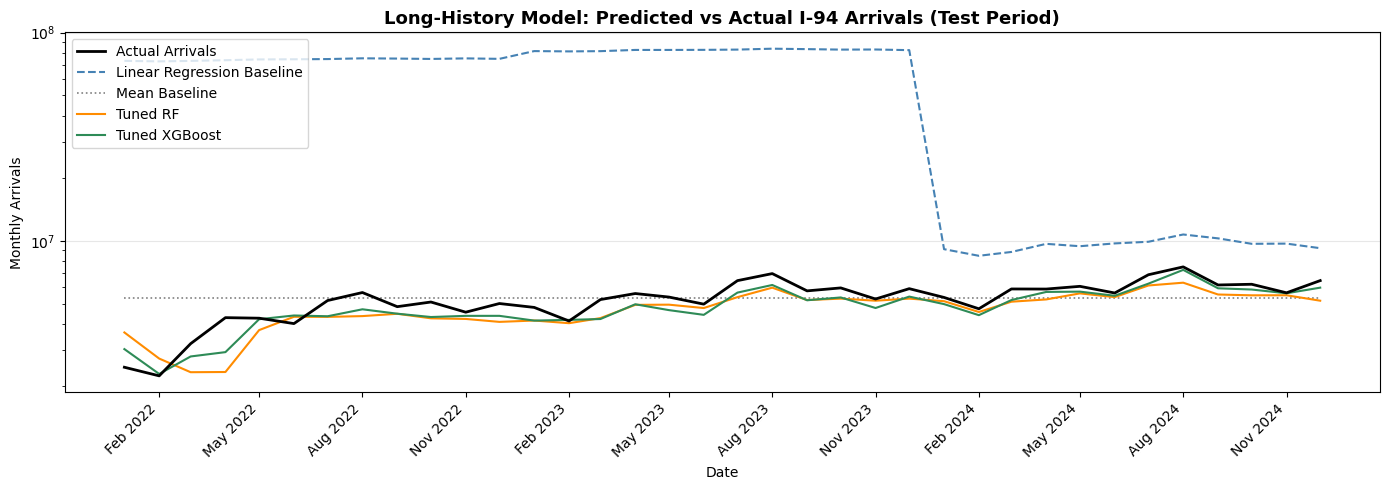

In [ ]:
# ── Collect long-history predictions ──────────────────────────────────────────
# Mean baseline
long_mean_pred = np.full(len(y_test), y_train.mean())

# Seasonal naïve (same month prior year)
long_naive_pred = df_full.loc[~train_mask_full, "arrivals_lag_12"].values

# Tuned RF and XGB (log-target versions — swap variable names if using non-log)
long_rf_pred  = rf_long_search.best_estimator_.predict(X_test)
long_xgb_pred = xgb_long_search.best_estimator_.predict(X_test)

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(long_test_dates, y_test.values,
        color="black", linewidth=2, label="Actual Arrivals", zorder=5)

ax.plot(long_test_dates, long_lr_pred,
        color="steelblue", linewidth=1.5, linestyle="--",
        label="Linear Regression Baseline")

ax.plot(long_test_dates, long_mean_pred,
        color="gray", linewidth=1.2, linestyle=":",
        label="Mean Baseline")

ax.plot(long_test_dates, long_rf_pred,
        color="darkorange", linewidth=1.5,
        label="Tuned RF")

ax.plot(long_test_dates, long_xgb_pred,
        color="seagreen", linewidth=1.5,
        label="Tuned XGBoost")

ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45, ha="right")

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M")
)

ax.set_title("Long-History Model: Predicted vs Actual I-94 Arrivals (Test Period)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Monthly Arrivals (Log Scale)")
ax.set_yscale("log")
ax.legend(loc="upper left")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

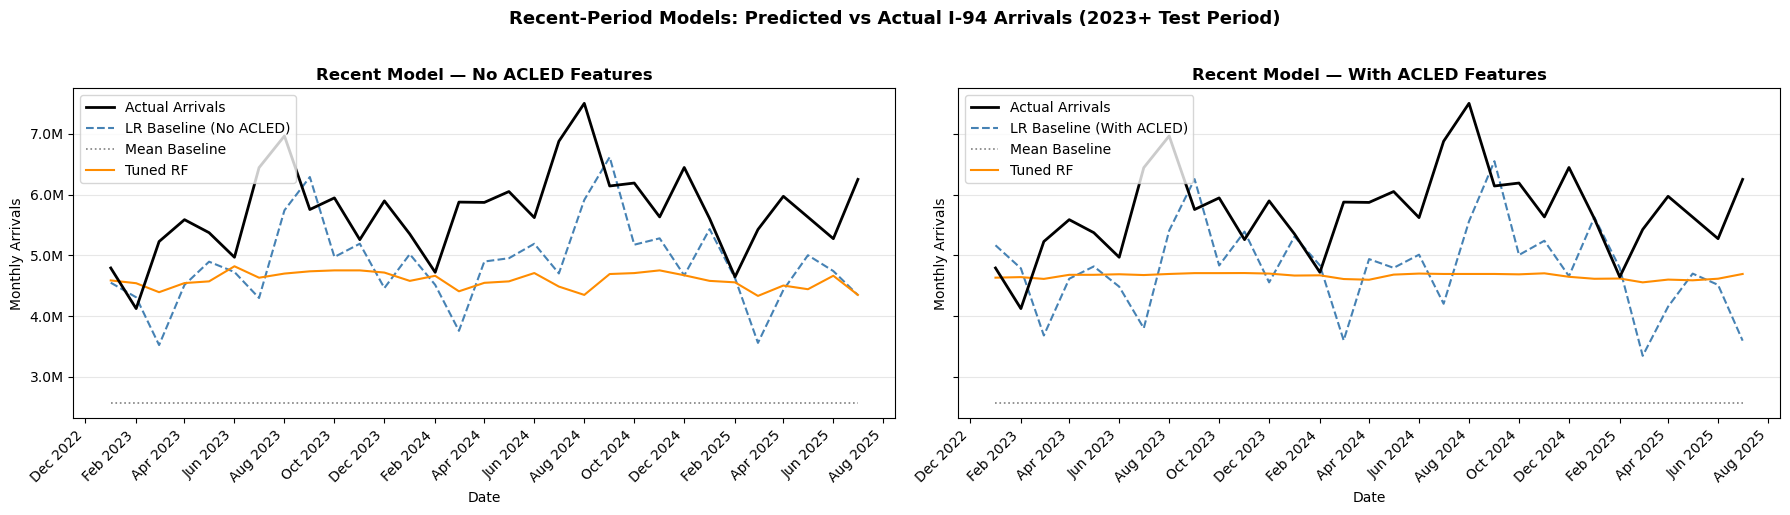

In [41]:
# ── Collect recent-period predictions ─────────────────────────────────────────
recent_mean_no_acled_pred = np.full(len(y_test_no_acled), y_train_no_acled.mean())
recent_mean_acled_pred    = np.full(len(y_test_acled),    y_train_acled.mean())

recent_naive_pred = df_acled_model.loc[~acled_mask, "arrivals_lag_12"].values

recent_rf_no_acled_pred  = rf_no_acled_search.best_estimator_.predict(X_test_no_acled)
recent_rf_acled_pred     = rf_acled_search.best_estimator_.predict(X_test_acled)

# ── Side-by-side subplots ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 5), sharey=True)

for ax, title, rf_pred, lr_pred, mean_pred, y_test_exp, lr_label in [
    (axes[0],
     "Recent Model — No ACLED Features",
     recent_rf_no_acled_pred,
     recent_lr_no_acled_pred,
     recent_mean_no_acled_pred,
     y_test_no_acled,
     "LR Baseline (No ACLED)"),
    (axes[1],
     "Recent Model — With ACLED Features",
     recent_rf_acled_pred,
     recent_lr_acled_pred,
     recent_mean_acled_pred,
     y_test_acled,
     "LR Baseline (With ACLED)"),
]:
    ax.plot(recent_test_dates, y_test_exp.values,
            color="black", linewidth=2, label="Actual Arrivals", zorder=5)

    ax.plot(recent_test_dates, lr_pred,
            color="steelblue", linewidth=1.5, linestyle="--",
            label=lr_label)

    ax.plot(recent_test_dates, mean_pred,
            color="gray", linewidth=1.2, linestyle=":",
            label="Mean Baseline")

    ax.plot(recent_test_dates, rf_pred,
            color="darkorange", linewidth=1.5,
            label="Tuned RF")

    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")

    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M")
    )

    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Date")
    ax.set_ylabel("Monthly Arrivals")
    ax.legend(loc="upper left")
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Recent-Period Models: Predicted vs Actual I-94 Arrivals (2023+ Test Period)",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

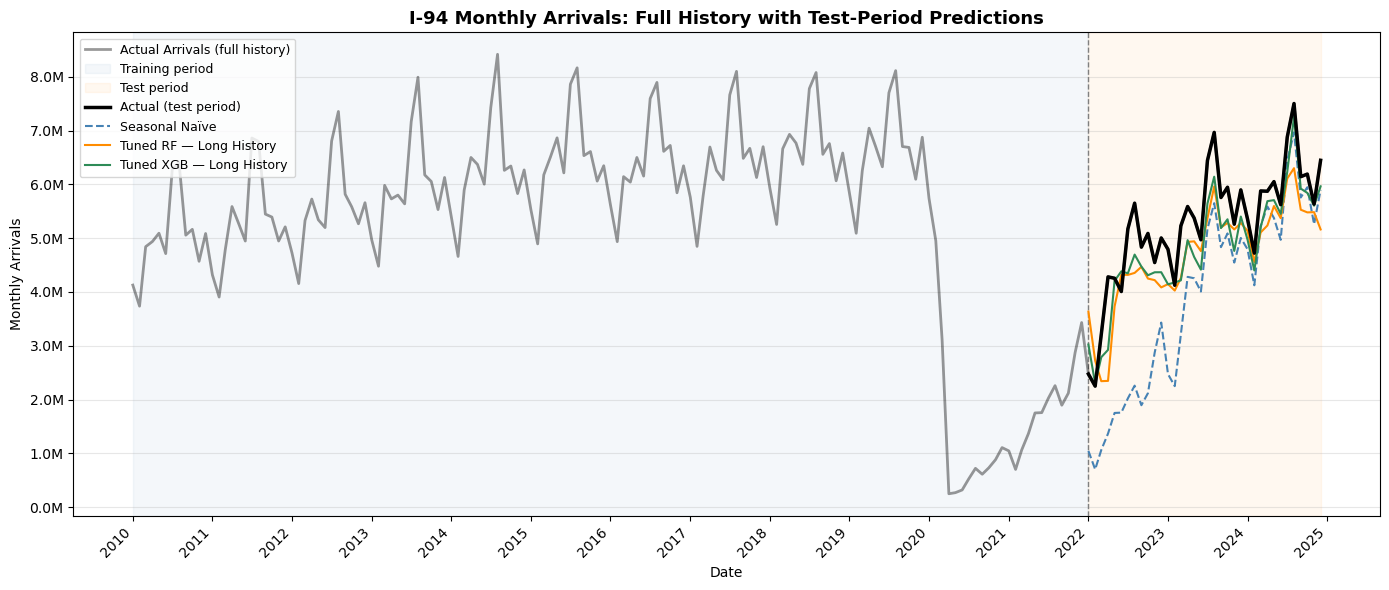

In [42]:
fig, ax = plt.subplots(figsize=(14, 6))

# Full actual series for context (training + test)
all_dates  = pd.to_datetime(df_full["date"].values)
all_actual = df_full["total_arrivals"].values

ax.plot(all_dates, all_actual,
        color="black", linewidth=2, alpha=0.4,
        label="Actual Arrivals (full history)", zorder=5)

# Shade the training vs test region
train_end = long_test_dates[0]
ax.axvspan(all_dates[0], train_end,
           alpha=0.06, color="steelblue", label="Training period")
ax.axvspan(train_end, all_dates[-1],
           alpha=0.06, color="darkorange", label="Test period")
ax.axvline(train_end, color="gray", linewidth=1, linestyle="--")

# Overlay test-period predictions
ax.plot(long_test_dates, y_test.values,
        color="black", linewidth=2.5, label="Actual (test period)", zorder=6)

ax.plot(long_test_dates, long_naive_pred,
        color="steelblue", linewidth=1.5, linestyle="--",
        label="Seasonal Naïve")

ax.plot(long_test_dates, long_rf_pred,
        color="darkorange", linewidth=1.5,
        label="Tuned RF — Long History")

ax.plot(long_test_dates, long_xgb_pred,
        color="seagreen", linewidth=1.5,
        label="Tuned XGB — Long History")

ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())
plt.xticks(rotation=45, ha="right")

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M")
)

ax.set_title("I-94 Monthly Arrivals: Full History with Test-Period Predictions",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Monthly Arrivals")
ax.legend(loc="upper left", fontsize=9)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

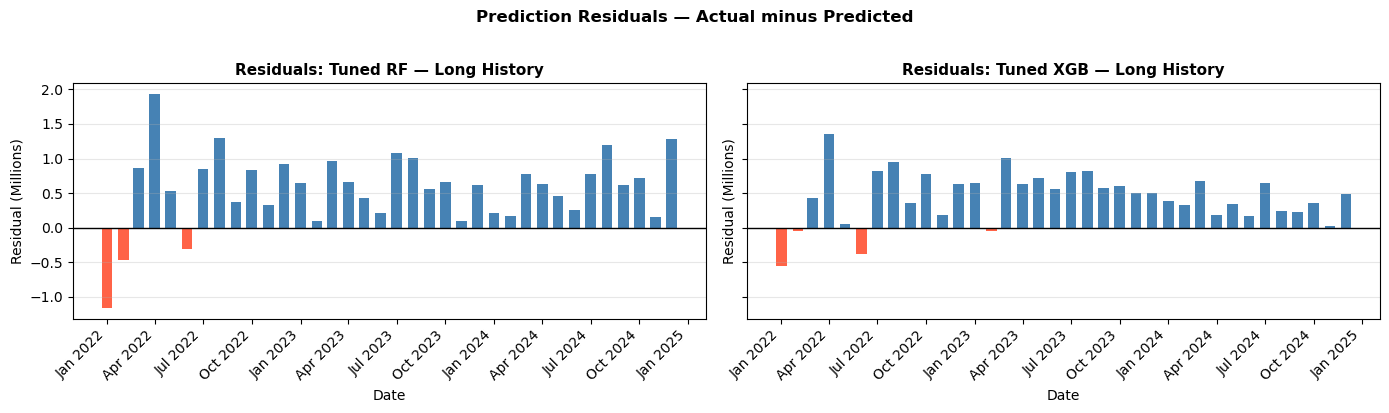

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

for ax, name, preds in [
    (axes[0], "Tuned RF — Long History",  long_rf_pred),
    (axes[1], "Tuned XGB — Long History", long_xgb_pred),
]:
    residuals = y_test.values - preds
    ax.bar(long_test_dates, residuals / 1e6,
           color=["tomato" if r < 0 else "steelblue" for r in residuals],
           width=20)
    ax.axhline(0, color="black", linewidth=1)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")
    ax.set_title(f"Residuals: {name}", fontsize=11, fontweight="bold")
    ax.set_xlabel("Date")
    ax.set_ylabel("Residual (Millions)")
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Prediction Residuals — Actual minus Predicted",
             fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()